In [ ]:
# Cell 1 – Importera bibliotek
    # Laddar verktyg för dataanalys, visualisering och supervised learning.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

In [ ]:
# Cell 2 – Ladda data
    # Läser in träningsdatan. Varje rad = en besökare/session.

df = pd.read_csv("../../data/training_sample_svenska.csv")

df.head()

,anvandar_id,klickat_varukorgsikon,lagt_till_fran_kategorisida,lagt_till_fran_produktsida,anvant_sorteringsfunktion,klickat_pa_produktbild,gatt_in_pa_kontosida,klickat_pa_kampanjbanner,sparat_i_onskelista,anvant_prissortering,...,gatt_till_produktspecifikation,gatt_till_leveransvillkor,tomt_varukorg,gatt_till_startsidan,anvant_mobil,anvant_dator,anvant_surfplatta,aterkommande_besokare,besokt_fran_svensk_plats,genomfort_bestallning
0,a720-6b732349-a720-4862-bd21-644732,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
1,a0c0-6b73247c-a0c0-4bd9-8baa-797356,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
2,86a8-6b735c67-86a8-407b-ba24-333055,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,1,0
3,6a3d-6b736346-6a3d-4085-934b-396834,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,1,0
4,b74a-6b737717-b74a-45c3-8c6a-421140,0,1,0,1,0,0,0,0,1,...,0,0,0,1,0,0,1,0,1,1


In [ ]:
# Cell 3 – Grundläggande överblick
    # Ger första överblicken: antal observationer, variabler, datatyper och 0/1-fördelningar.

print("Antal rader och kolumner:", df.shape)

display(df.head())
display(df.info())
display(df.describe())

Antal rader och kolumner: (455401, 25)


,anvandar_id,klickat_varukorgsikon,lagt_till_fran_kategorisida,lagt_till_fran_produktsida,anvant_sorteringsfunktion,klickat_pa_produktbild,gatt_in_pa_kontosida,klickat_pa_kampanjbanner,sparat_i_onskelista,anvant_prissortering,...,gatt_till_produktspecifikation,gatt_till_leveransvillkor,tomt_varukorg,gatt_till_startsidan,anvant_mobil,anvant_dator,anvant_surfplatta,aterkommande_besokare,besokt_fran_svensk_plats,genomfort_bestallning
0,a720-6b732349-a720-4862-bd21-644732,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
1,a0c0-6b73247c-a0c0-4bd9-8baa-797356,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
2,86a8-6b735c67-86a8-407b-ba24-333055,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,1,0
3,6a3d-6b736346-6a3d-4085-934b-396834,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,1,0
4,b74a-6b737717-b74a-45c3-8c6a-421140,0,1,0,1,0,0,0,0,1,...,0,0,0,1,0,0,1,0,1,1


<class 'pandas.DataFrame'>
RangeIndex: 455401 entries, 0 to 455400
Data columns (total 25 columns):
 #   Column                          Non-Null Count   Dtype
---  ------                          --------------   -----
 0   anvandar_id                     455401 non-null  str  
 1   klickat_varukorgsikon           455401 non-null  int64
 2   lagt_till_fran_kategorisida     455401 non-null  int64
 3   lagt_till_fran_produktsida      455401 non-null  int64
 4   anvant_sorteringsfunktion       455401 non-null  int64
 5   klickat_pa_produktbild          455401 non-null  int64
 6   gatt_in_pa_kontosida            455401 non-null  int64
 7   klickat_pa_kampanjbanner        455401 non-null  int64
 8   sparat_i_onskelista             455401 non-null  int64
 9   anvant_prissortering            455401 non-null  int64
 10  stangt_liten_varukorg_popup     455401 non-null  int64
 11  kollat_fraktkostnad             455401 non-null  int64
 12  kollat_angerratt                455401 non-null  int64


None

,klickat_varukorgsikon,lagt_till_fran_kategorisida,lagt_till_fran_produktsida,anvant_sorteringsfunktion,klickat_pa_produktbild,gatt_in_pa_kontosida,klickat_pa_kampanjbanner,sparat_i_onskelista,anvant_prissortering,stangt_liten_varukorg_popup,...,gatt_till_produktspecifikation,gatt_till_leveransvillkor,tomt_varukorg,gatt_till_startsidan,anvant_mobil,anvant_dator,anvant_surfplatta,aterkommande_besokare,besokt_fran_svensk_plats,genomfort_bestallning
count,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,...,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000
mean,0.099150,0.074521,0.112916,0.036849,0.026735,0.003570,0.016208,0.003511,0.230362,0.017277,...,0.000389,0.005542,0.001096,0.290024,0.680706,0.194220,0.128364,0.534915,0.933224,0.041926
std,0.298864,0.262617,0.316490,0.188391,0.161307,0.059647,0.126274,0.059151,0.421065,0.130302,...,0.019711,0.074241,0.033084,0.453773,0.466204,0.395599,0.334495,0.498780,0.249634,0.200420
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# Cell 4 – Kontrollera missing values och dubletter
    # Visar om datan behöver rensas. Om allt är 0 saknade värden är datan ganska ren.

print("Saknade värden per kolumn:")
display(df.isna().sum())

print("Antal duplicerade rader:", df.duplicated().sum())
print("Antal duplicerade användar-ID:", df["anvandar_id"].duplicated().sum())

Saknade värden per kolumn:


anvandar_id                       0
klickat_varukorgsikon             0
lagt_till_fran_kategorisida       0
lagt_till_fran_produktsida        0
anvant_sorteringsfunktion         0
klickat_pa_produktbild            0
gatt_in_pa_kontosida              0
klickat_pa_kampanjbanner          0
sparat_i_onskelista               0
anvant_prissortering              0
stangt_liten_varukorg_popup       0
kollat_fraktkostnad               0
kollat_angerratt                  0
loggat_in                         0
gatt_till_kassan                  0
gatt_till_produktspecifikation    0
gatt_till_leveransvillkor         0
tomt_varukorg                     0
gatt_till_startsidan              0
anvant_mobil                      0
anvant_dator                      0
anvant_surfplatta                 0
aterkommande_besokare             0
besokt_fran_svensk_plats          0
genomfort_bestallning             0
dtype: int64

Antal duplicerade rader: 0
Antal duplicerade användar-ID: 0


In [ ]:
# Cell 5 – Definiera input och output
    # Detta följer supervised learning-logiken: modellen tränas på input-output-par och lär sig förutsäga output från input.

target = "genomfort_bestallning"

X = df.drop(columns=["anvandar_id", target])
y = df[target]

print("Inputvariabler:")
print(X.columns.tolist())

print("\nOutput/target:")
print(target)

Inputvariabler:
['klickat_varukorgsikon', 'lagt_till_fran_kategorisida', 'lagt_till_fran_produktsida', 'anvant_sorteringsfunktion', 'klickat_pa_produktbild', 'gatt_in_pa_kontosida', 'klickat_pa_kampanjbanner', 'sparat_i_onskelista', 'anvant_prissortering', 'stangt_liten_varukorg_popup', 'kollat_fraktkostnad', 'kollat_angerratt', 'loggat_in', 'gatt_till_kassan', 'gatt_till_produktspecifikation', 'gatt_till_leveransvillkor', 'tomt_varukorg', 'gatt_till_startsidan', 'anvant_mobil', 'anvant_dator', 'anvant_surfplatta', 'aterkommande_besokare', 'besokt_fran_svensk_plats']

Output/target:
genomfort_bestallning


,antal,procent
genomfort_bestallning,,
0,436308,95.81
1,19093,4.19


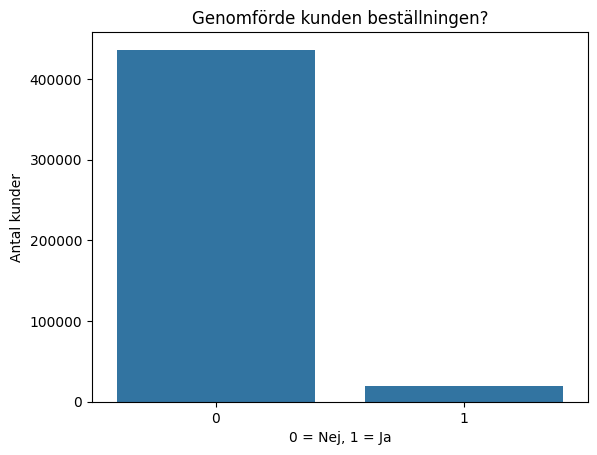

In [ ]:
# Cell 6 – Hur många köpte?
    # Visar om datasetet är obalanserat. Om väldigt få köper är accuracy ensamt inte tillräckligt; vi behöver även precision, recall och F1.

purchase_counts = y.value_counts()
purchase_percent = y.value_counts(normalize=True) * 100

display(pd.DataFrame({
    "antal": purchase_counts,
    "procent": purchase_percent.round(2)
}))

sns.countplot(x=y)
plt.title("Genomförde kunden beställningen?")
plt.xlabel("0 = Nej, 1 = Ja")
plt.ylabel("Antal kunder")
plt.show()

In [ ]:
# Fråga 1: Vad avgör om kunden genomför köp?

# Cell 7 – Köpandel per variabel, alla inputvariabler
    # Jämför köpandel när variabeln är 0 vs 1.
    # Exempel: köper kunder oftare när de gått till kassan?

purchase_rate = []

for col in X.columns:
    rate_when_0 = df[df[col] == 0][target].mean()
    rate_when_1 = df[df[col] == 1][target].mean()
    difference = rate_when_1 - rate_when_0
    
    purchase_rate.append({
        "variabel": col,
        "köpandel_när_0": rate_when_0,
        "köpandel_när_1": rate_when_1,
        "skillnad": difference
    })

purchase_rate_df = pd.DataFrame(purchase_rate)
purchase_rate_df = purchase_rate_df.sort_values("skillnad", ascending=False)

display(purchase_rate_df)

,variabel,köpandel_när_0,köpandel_när_1,skillnad
10,kollat_fraktkostnad,0.000462,0.659938,0.659476
13,gatt_till_kassan,0.000000,0.523512,0.523512
12,loggat_in,0.000282,0.469192,0.468910
0,klickat_varukorgsikon,0.013446,0.300689,0.287243
2,lagt_till_fran_produktsida,0.012293,0.274727,0.262434
1,lagt_till_fran_kategorisida,0.025566,0.245101,0.219536
9,stangt_liten_varukorg_popup,0.038205,0.253559,0.215354
5,gatt_in_pa_kontosida,0.041238,0.233702,0.192464
16,tomt_varukorg,0.041754,0.198397,0.156643
11,kollat_angerratt,0.040778,0.165789,0.125011


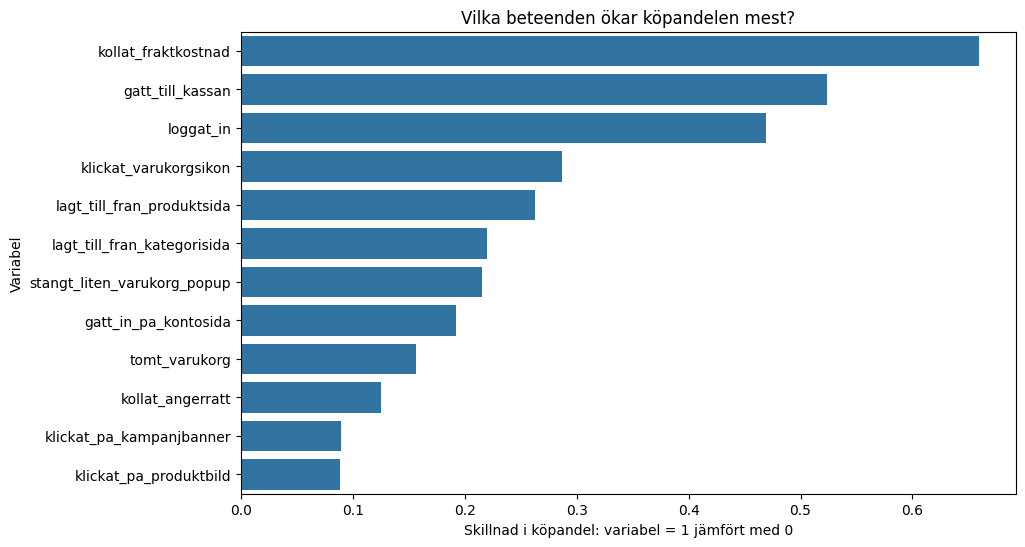

In [ ]:
# Cell 8 – Visualisera viktigaste beteenden
    # Visar vilka beteenden som verkar mest kopplade till köp.

top_features = purchase_rate_df.head(12)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, x="skillnad", y="variabel")
plt.title("Vilka beteenden ökar köpandelen mest?")
plt.xlabel("Skillnad i köpandel: variabel = 1 jämfört med 0")
plt.ylabel("Variabel")
plt.show()

In [ ]:
# Fråga 2: Var i processen tappar vi kunder?

# Cell 9 – Definiera kundresa/funnel-variabler 
    # Visar hur många som gör varje handling och hur ofta de sedan köper.
    # Det hjälper er förstå var Webhallen tappar kunder.

funnel_features = [
    "klickat_varukorgsikon",
    "lagt_till_fran_kategorisida",
    "lagt_till_fran_produktsida",
    "anvant_sorteringsfunktion",
    "klickat_pa_produktbild",
    "gatt_in_pa_kontosida",
    "klickat_pa_kampanjbanner",
    "sparat_i_onskelista",
    "anvant_prissortering",
    "stangt_liten_varukorg_popup",
    "kollat_fraktkostnad",
    "kollat_angerratt",
    "loggat_in",
    "gatt_till_kassan",
    "gatt_till_produktspecifikation",
    "gatt_till_leveransvillkor",
    "tomt_varukorg",
    "gatt_till_startsidan"
]

funnel_summary = []

for col in funnel_features:
    users_with_action = df[col].sum()
    purchase_rate_action = df[df[col] == 1][target].mean()
    
    funnel_summary.append({
        "steg": col,
        "antal_som_gjort_handlingen": users_with_action,
        "köpandel_bland_dessa": purchase_rate_action
    })

funnel_df = pd.DataFrame(funnel_summary)
funnel_df = funnel_df.sort_values("antal_som_gjort_handlingen", ascending=False)

display(funnel_df)

,steg,antal_som_gjort_handlingen,köpandel_bland_dessa
17,gatt_till_startsidan,132077,0.091401
8,anvant_prissortering,104907,0.098659
2,lagt_till_fran_produktsida,51422,0.274727
0,klickat_varukorgsikon,45153,0.300689
12,loggat_in,40444,0.469192
13,gatt_till_kassan,36471,0.523512
1,lagt_till_fran_kategorisida,33937,0.245101
10,kollat_fraktkostnad,28633,0.659938
3,anvant_sorteringsfunktion,16781,0.097908
4,klickat_pa_produktbild,12175,0.128378


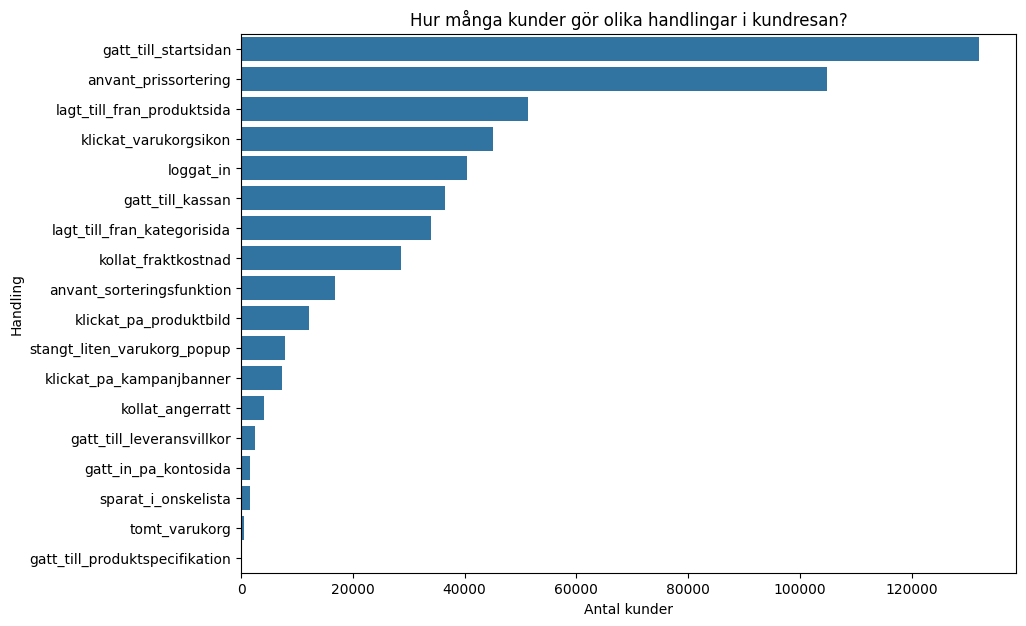

In [ ]:
# Cell 10 – Visualisera kundresan 
    # Visar vilka steg många/få kunder når.

plt.figure(figsize=(10, 7))
sns.barplot(
    data=funnel_df,
    x="antal_som_gjort_handlingen",
    y="steg"
)
plt.title("Hur många kunder gör olika handlingar i kundresan?")
plt.xlabel("Antal kunder")
plt.ylabel("Handling")
plt.show()

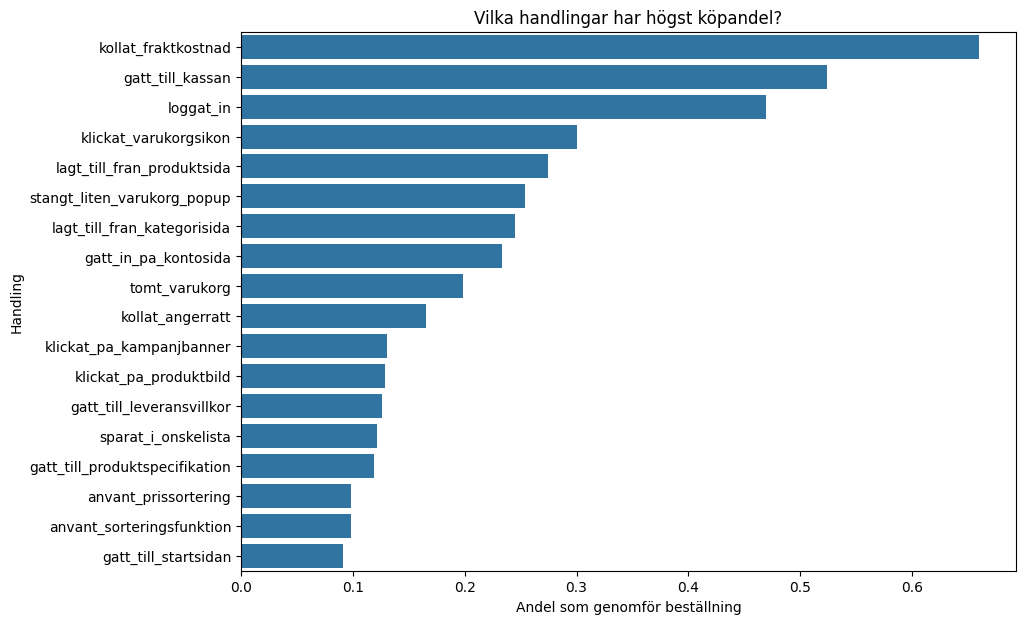

In [ ]:
# Cell 11 – Köpandel i kundresan 
    # Visar vilka handlingar som starkast signalerar köpintention.

funnel_df_sorted = funnel_df.sort_values("köpandel_bland_dessa", ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=funnel_df_sorted,
    x="köpandel_bland_dessa",
    y="steg"
)
plt.title("Vilka handlingar har högst köpandel?")
plt.xlabel("Andel som genomför beställning")
plt.ylabel("Handling")
plt.show()

In [ ]:
# Fråga 3: Vilka kunder köper mest?

# Cell 12 – Segmenteringsvariabler 
    # Jämför kundgrupper: mobil/dator/surfplatta, återkommande, inloggade.

segment_features = [
    "anvant_mobil",
    "anvant_dator",
    "anvant_surfplatta",
    "aterkommande_besokare",
    "besokt_fran_svensk_plats",
    "loggat_in"
]

segment_summary = []

for col in segment_features:
    rate_0 = df[df[col] == 0][target].mean()
    rate_1 = df[df[col] == 1][target].mean()
    
    segment_summary.append({
        "segmentvariabel": col,
        "köpandel_när_0": rate_0,
        "köpandel_när_1": rate_1,
        "skillnad": rate_1 - rate_0
    })

segment_df = pd.DataFrame(segment_summary).sort_values("skillnad", ascending=False)

display(segment_df)

,segmentvariabel,köpandel_när_0,köpandel_när_1,skillnad
5,loggat_in,0.000282,0.469192,0.468910
4,besokt_fran_svensk_plats,0.018218,0.043622,0.025404
1,anvant_dator,0.037084,0.062014,0.024930
3,aterkommande_besokare,0.028966,0.053194,0.024228
2,anvant_surfplatta,0.040623,0.050772,0.010150
0,anvant_mobil,0.054482,0.036036,-0.018445


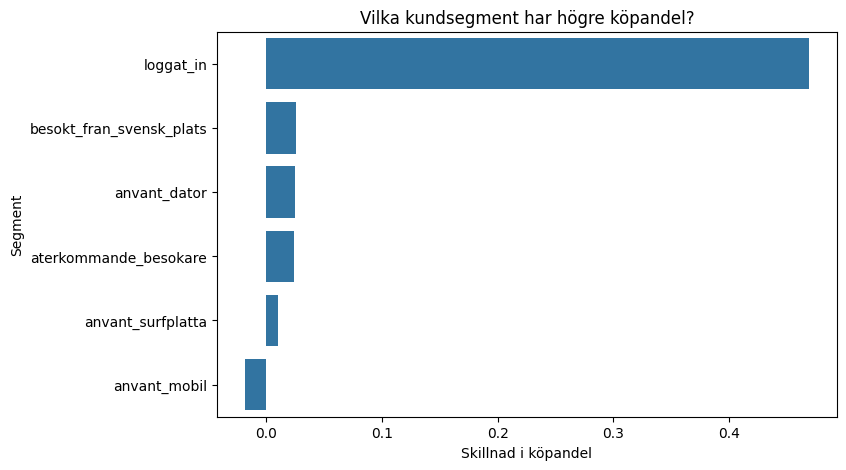

In [23]:
# Cell 13 – Visualisera segment 
    # Ger affärsinsikt: vilka kunder Webhallen bör prioritera.

plt.figure(figsize=(8, 5))
sns.barplot(data=segment_df, x="skillnad", y="segmentvariabel")
plt.title("Vilka kundsegment har högre köpandel?")
plt.xlabel("Skillnad i köpandel")
plt.ylabel("Segment")
plt.show()

In [24]:
# Modell 1: Logistic Regression
# Cell 14 – Intern train/test split från training_sample
    # Vi använder bara training_sample här eftersom den innehåller facit: genomfort_bestallning.
    # Kaggle testing_sample används senare för slutprediktioner utan facit.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nKöpandel i y_train:")
print(y_train.value_counts(normalize=True))

print("\nKöpandel i y_test:")
print(y_test.value_counts(normalize=True))

X_train: (364320, 23)
X_test: (91081, 23)
y_train: (364320,)
y_test: (91081,)

Köpandel i y_train:
genomfort_bestallning
0    0.958075
1    0.041925
Name: proportion, dtype: float64

Köpandel i y_test:
genomfort_bestallning
0    0.95807
1    0.04193
Name: proportion, dtype: float64


In [25]:
# Cell 15 – Skala data för Logistic Regression och KNN
    # Skalar inputvariabler. Viktigt för KNN och ofta bra för logistisk regression. Skalaren tränas bara på träningsdata för att undvika dataläckage.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Cell 16 – Träna Logistic Regression
    # Tränar en modell som beräknar sannolikheten att kunden genomför köp. Logistic Regression passar binära utfall som 0/1.

log_model = LogisticRegression(max_iter=1000, class_weight="balanced")

log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)
log_proba = log_model.predict_proba(X_test_scaled)[:, 1]

In [27]:
# Cell 17 – Utvärdera Logistic Regression
    # Visar hur bra modellen är. Viktigt: fokusera inte bara på accuracy, utan även precision, recall och F1.

print("Accuracy:", accuracy_score(y_test, log_pred))
print("ROC AUC:", roc_auc_score(y_test, log_proba))

print("\nClassification report:")
print(classification_report(y_test, log_pred))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, log_pred))

Accuracy: 0.9920400522611741
ROC AUC: 0.9973997353450771

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     87262
           1       0.85      0.99      0.91      3819

    accuracy                           0.99     91081
   macro avg       0.92      0.99      0.95     91081
weighted avg       0.99      0.99      0.99     91081


Confusion matrix:
[[86567   695]
 [   30  3789]]


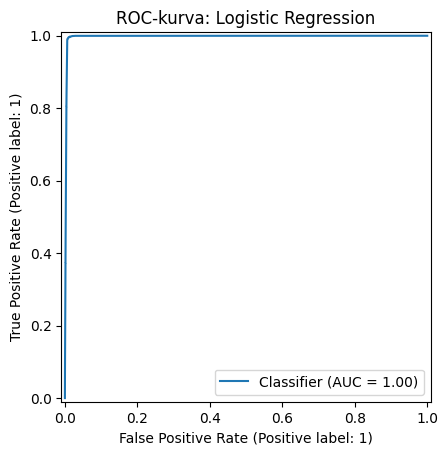

In [28]:
# Cell 18 – ROC-kurva Logistic Regression
    # Visar hur bra modellen skiljer mellan kunder som köper och inte köper. AUC över 0.7 är ofta acceptabelt, 0.8+ bra.

RocCurveDisplay.from_predictions(y_test, log_proba)
plt.title("ROC-kurva: Logistic Regression")
plt.show()

In [29]:
# Modell 2: Decision Tree
    # Tränar beslutsträd. Detta passar extra bra eftersom era variabler är 0/1 och kan tolkas som ja/nej-beslut.

tree_model = DecisionTreeClassifier(
    max_depth=4,
    class_weight="balanced",
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)
tree_proba = tree_model.predict_proba(X_test)[:, 1]

In [30]:
# Cell 20 – Utvärdera beslutsträd
    # Jämför beslutsträdets prediktioner mot verkligt köp/ej köp.


print("Accuracy:", accuracy_score(y_test, tree_pred))
print("ROC AUC:", roc_auc_score(y_test, tree_proba))

print("\nClassification report:")
print(classification_report(y_test, tree_pred))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, tree_pred))

Accuracy: 0.9931050383724377
ROC AUC: 0.9968212914431184

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     87262
           1       0.86      0.99      0.92      3819

    accuracy                           0.99     91081
   macro avg       0.93      0.99      0.96     91081
weighted avg       0.99      0.99      0.99     91081


Confusion matrix:
[[86670   592]
 [   36  3783]]


kollat_fraktkostnad               9.618498e-01
gatt_till_kassan                  3.586258e-02
klickat_varukorgsikon             1.478073e-03
loggat_in                         4.409437e-04
lagt_till_fran_kategorisida       3.285097e-04
gatt_till_leveransvillkor         3.324819e-05
besokt_fran_svensk_plats          6.888570e-06
klickat_pa_kampanjbanner          2.663580e-14
klickat_pa_produktbild            0.000000e+00
anvant_sorteringsfunktion         0.000000e+00
lagt_till_fran_produktsida        0.000000e+00
gatt_in_pa_kontosida              0.000000e+00
anvant_prissortering              0.000000e+00
stangt_liten_varukorg_popup       0.000000e+00
sparat_i_onskelista               0.000000e+00
gatt_till_produktspecifikation    0.000000e+00
kollat_angerratt                  0.000000e+00
gatt_till_startsidan              0.000000e+00
tomt_varukorg                     0.000000e+00
anvant_mobil                      0.000000e+00
anvant_dator                      0.000000e+00
anvant_surfpl

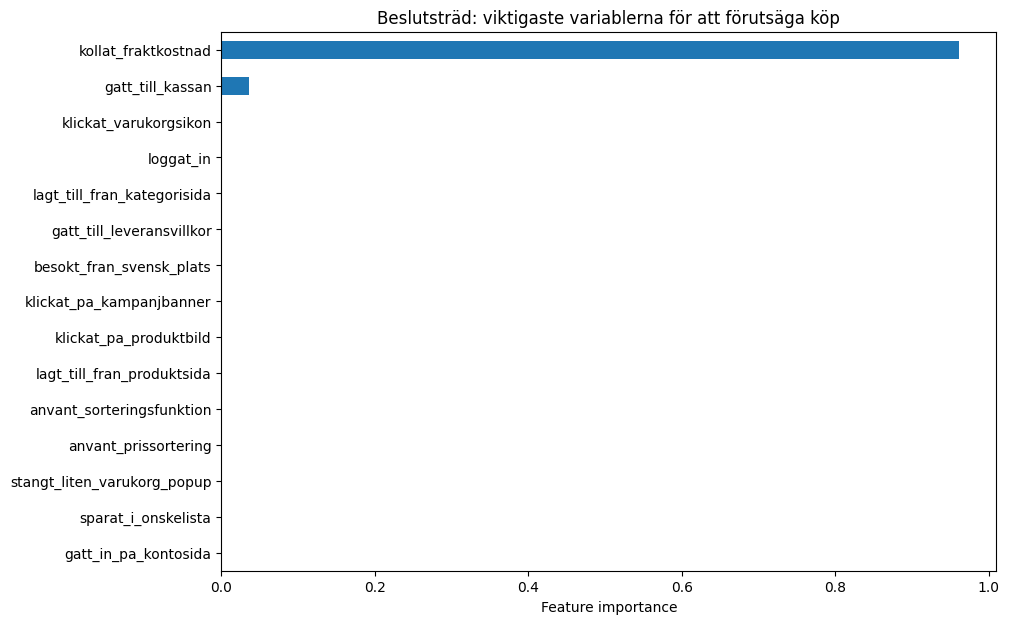

In [31]:
# Cell 21 – Feature importance från beslutsträd
    # Visar vilka variabler modellen tycker är viktigast.

tree_importance = pd.Series(
    tree_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

display(tree_importance)

plt.figure(figsize=(10, 7))
tree_importance.head(15).sort_values().plot(kind="barh")
plt.title("Beslutsträd: viktigaste variablerna för att förutsäga köp")
plt.xlabel("Feature importance")
plt.show()

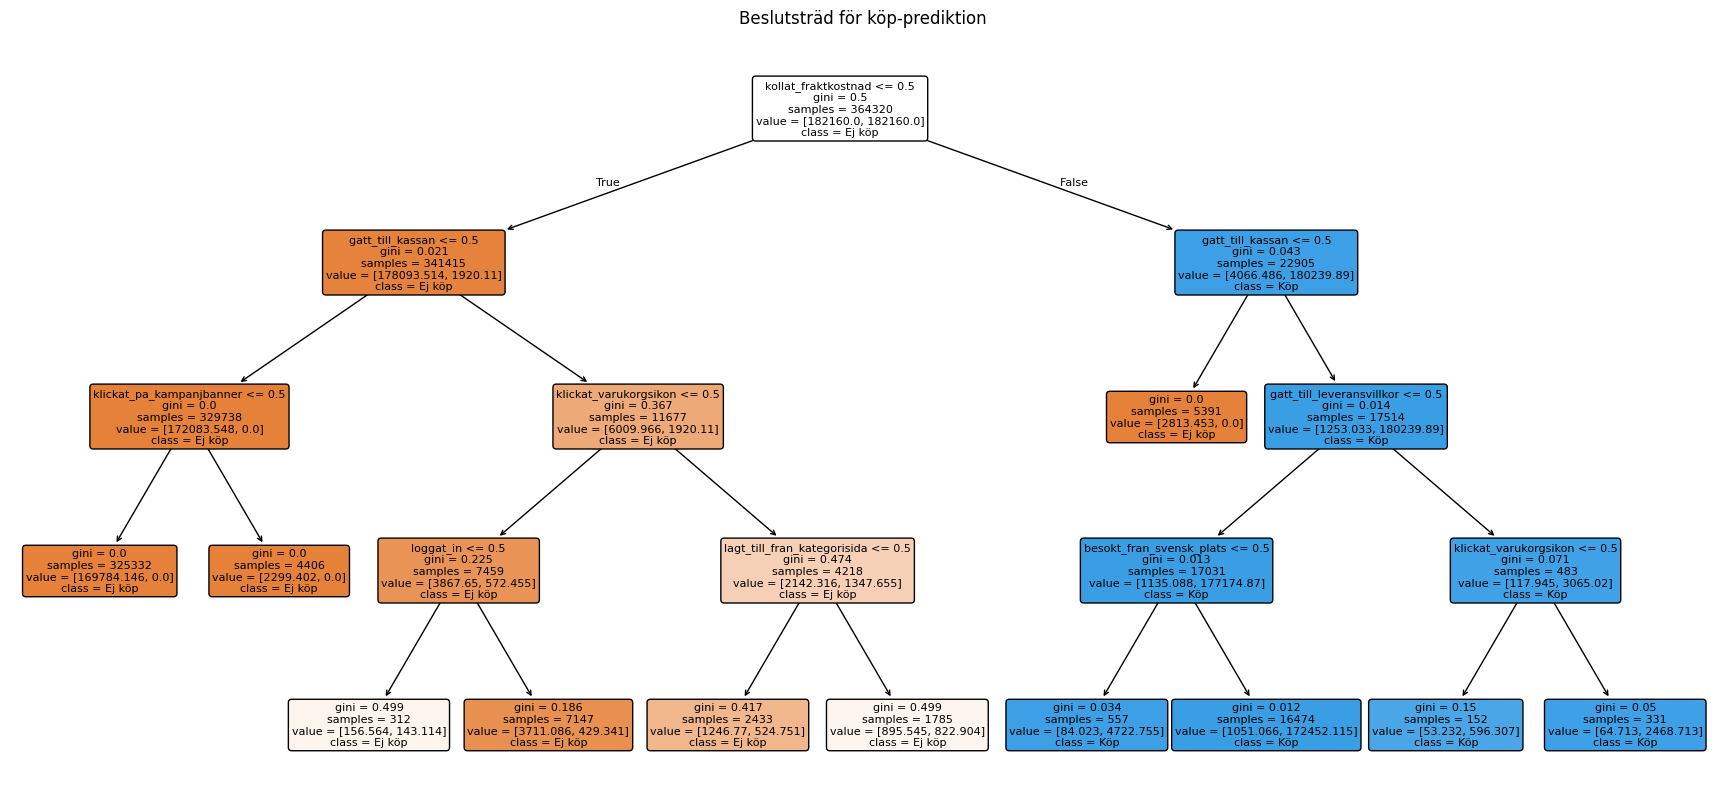

In [ ]:
# Cell 22 – Rita beslutsträdet
    # Ger en visuell modell: “om kunden gjorde X, gå åt detta håll”. 

plt.figure(figsize=(22, 10))

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["Ej köp", "Köp"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Beslutsträd för köp-prediktion")
plt.show()

In [33]:
# Modell 3: KNN
# Cell 23 – Träna KNN
    # KNN jämför en kund med liknande kunder och gissar baserat på närmaste grannar. KNN kräver skalning eftersom den bygger på avstånd.

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)
knn_proba = knn_model.predict_proba(X_test_scaled)[:, 1]

In [34]:
# Cell 24 – Utvärdera KNN
# Visar om KNN är bättre eller sämre än Logistic Regression och Decision Tree.

print("Accuracy:", accuracy_score(y_test, knn_pred))
print("ROC AUC:", roc_auc_score(y_test, knn_proba))

print("\nClassification report:")
print(classification_report(y_test, knn_pred))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, knn_pred))

Accuracy: 0.9919412391168301
ROC AUC: 0.9922191067968068

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     87262
           1       0.87      0.95      0.91      3819

    accuracy                           0.99     91081
   macro avg       0.93      0.97      0.95     91081
weighted avg       0.99      0.99      0.99     91081


Confusion matrix:
[[86720   542]
 [  192  3627]]


,modell,accuracy,roc_auc
0,Logistic Regression,0.992040,0.997400
1,Decision Tree,0.993105,0.996821
2,KNN,0.991941,0.992219


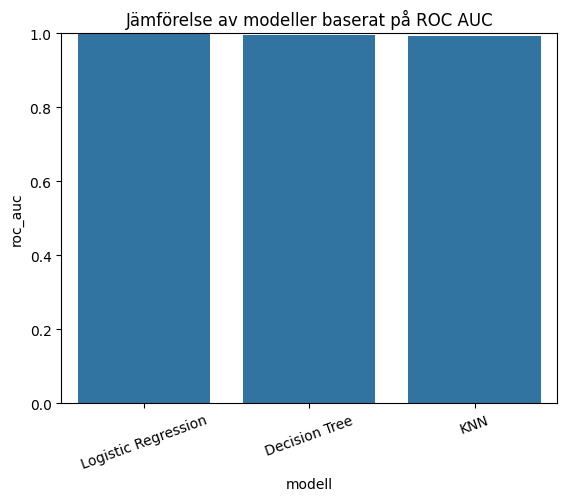

In [35]:
# Jämför modeller
# Cell 25 – Modelljämförelse

model_results = pd.DataFrame({
    "modell": ["Logistic Regression", "Decision Tree", "KNN"],
    "accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, tree_pred),
        accuracy_score(y_test, knn_pred)
    ],
    "roc_auc": [
        roc_auc_score(y_test, log_proba),
        roc_auc_score(y_test, tree_proba),
        roc_auc_score(y_test, knn_proba)
    ]
})

display(model_results)

sns.barplot(data=model_results, x="modell", y="roc_auc")
plt.title("Jämförelse av modeller baserat på ROC AUC")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

In [36]:
# Extra: PCA enligt uppgiften
# Cell 26 – PCA med Logistic Regression
# Testar om datan kan reduceras till två huvudkomponenter och ändå förutsäga köp.

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

pca_log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
pca_log_model.fit(X_train_pca, y_train)

pca_pred = pca_log_model.predict(X_test_pca)
pca_proba = pca_log_model.predict_proba(X_test_pca)[:, 1]

print("Accuracy PCA + Logistic Regression:", accuracy_score(y_test, pca_pred))
print("ROC AUC PCA + Logistic Regression:", roc_auc_score(y_test, pca_proba))
print(classification_report(y_test, pca_pred))


Accuracy PCA + Logistic Regression: 0.9660631745369507
ROC AUC PCA + Logistic Regression: 0.992057203058747
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     87262
           1       0.55      0.99      0.71      3819

    accuracy                           0.97     91081
   macro avg       0.78      0.98      0.85     91081
weighted avg       0.98      0.97      0.97     91081



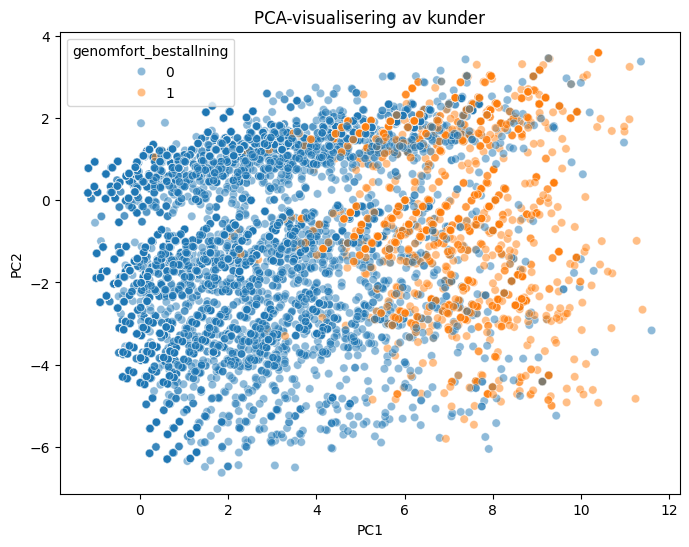

In [37]:
# Cell 27 – Visualisera PCA
# Visar om köpare och icke-köpare tenderar att separeras visuellt.

pca_plot_df = pd.DataFrame({
    "PC1": X_test_pca[:, 0],
    "PC2": X_test_pca[:, 1],
    "genomfort_bestallning": y_test.values
})

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_plot_df,
    x="PC1",
    y="PC2",
    hue="genomfort_bestallning",
    alpha=0.5
)
plt.title("PCA-visualisering av kunder")
plt.show()

In [38]:
# Affärsinsikter
# Cell 28 – Samla toppinsikter automatiskt
# Samlar det viktigaste ni kan använda i presentationen.

print("Topp 10 beteenden med störst skillnad i köpandel:")
display(purchase_rate_df.head(10))

print("Topp 10 viktigaste variabler enligt beslutsträd:")
display(tree_importance.head(10))

print("Modelljämförelse:")
display(model_results)


Topp 10 beteenden med störst skillnad i köpandel:


,variabel,köpandel_när_0,köpandel_när_1,skillnad
10,kollat_fraktkostnad,0.000462,0.659938,0.659476
13,gatt_till_kassan,0.000000,0.523512,0.523512
12,loggat_in,0.000282,0.469192,0.468910
0,klickat_varukorgsikon,0.013446,0.300689,0.287243
2,lagt_till_fran_produktsida,0.012293,0.274727,0.262434
1,lagt_till_fran_kategorisida,0.025566,0.245101,0.219536
9,stangt_liten_varukorg_popup,0.038205,0.253559,0.215354
5,gatt_in_pa_kontosida,0.041238,0.233702,0.192464
16,tomt_varukorg,0.041754,0.198397,0.156643
11,kollat_angerratt,0.040778,0.165789,0.125011


Topp 10 viktigaste variabler enligt beslutsträd:


kollat_fraktkostnad            9.618498e-01
gatt_till_kassan               3.586258e-02
klickat_varukorgsikon          1.478073e-03
loggat_in                      4.409437e-04
lagt_till_fran_kategorisida    3.285097e-04
gatt_till_leveransvillkor      3.324819e-05
besokt_fran_svensk_plats       6.888570e-06
klickat_pa_kampanjbanner       2.663580e-14
klickat_pa_produktbild         0.000000e+00
anvant_sorteringsfunktion      0.000000e+00
dtype: float64

Modelljämförelse:


,modell,accuracy,roc_auc
0,Logistic Regression,0.992040,0.997400
1,Decision Tree,0.993105,0.996821
2,KNN,0.991941,0.992219


In [39]:
# Cell 29 – Exempelprediktion: ny kund
# Visar hur Webhallen hypotetiskt skulle kunna använda modellen på en ny kund.

example_customer = X.iloc[[0]].copy()

predicted_probability = log_model.predict_proba(
    scaler.transform(example_customer)
)[:, 1][0]

predicted_class = log_model.predict(
    scaler.transform(example_customer)
)[0]

print("Predicerad sannolikhet för köp:", round(predicted_probability, 3))
print("Predicerad klass:", predicted_class)

Predicerad sannolikhet för köp: 0.0
Predicerad klass: 0
